Importer les lib



Prediction ventes
==============================================================
PROJET : Prédiction des ventes futures d'une entreprise
Dataset : Store Sales - Time Series Forecasting (Kaggle)
           Corporación Favorita (supermarchés, Équateur)
==============================================================

OBJECTIF
--------
Prédire les ventes journalières par magasin et par famille de produits,
à partir de l'historique, des promotions, des jours fériés et du prix
du pétrole (indicateur économique clé en Équateur), pour aider les
responsables à décider des stocks, achats, marketing et planification.

DONNÉES REQUISES (à télécharger sur Kaggle avant d'exécuter ce script)
------------------------------------------------------------
1. Aller sur : https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data
2. Télécharger : train.csv, stores.csv, oil.csv, holidays_events.csv,
   transactions.csv
3. Placer tous les fichiers dans le même dossier que ce script

NOTE SUR LA TAILLE
-------------------
train.csv contient ~3 millions de lignes (54 magasins x 33 familles de
produits x ~1700 jours). Pour un premier projet, ce script permet de
filtrer sur un sous-ensemble (magasin(s) et/ou familles) via les
variables FILTRE_MAGASINS et FILTRE_FAMILLES ci-dessous, afin de garder
des temps d'exécution raisonnables. Mets-les à None pour tout utiliser.

STRUCTURE DU SCRIPT
--------------------
1. Chargement et fusion des données (train + stores + oil + holidays)
2. Nettoyage
3. Feature engineering (dates, lags, moyennes mobiles, prix du pétrole)
4. Split chronologique
5. Entraînement de plusieurs modèles
6. Évaluation (MAE, RMSE, RMSLE - métrique officielle de la compétition)
7. Interprétation métier (importance des variables)
8. Sauvegarde du modèle final
"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

data set

In [ ]:
CHEMIN_TRAIN = "data/train.csv"
CHEMIN_STORES = "data/stores.csv"
CHEMIN_OIL = "data/oil.csv"
CHEMIN_HOLIDAYS = "data/holidays_events.csv"

# Pour limiter la taille (recommandé pour un premier essai) :
# ex. FILTRE_MAGASINS = [1, 2, 3]  ou None pour tout garder
FILTRE_MAGASINS = None
FILTRE_FAMILLES = None  # ex. ["GROCERY I", "BEVERAGES"]


# 1. CHARGEMENT ET FUSION DES DONNÉES

In [ ]:
print("Chargement des données...")
df = pd.read_csv(CHEMIN_TRAIN, parse_dates=["date"])
df_stores = pd.read_csv(CHEMIN_STORES)
df_oil = pd.read_csv(CHEMIN_OIL, parse_dates=["date"])
df_holidays = pd.read_csv(CHEMIN_HOLIDAYS, parse_dates=["date"])

if FILTRE_MAGASINS is not None:
    df = df[df["store_nbr"].isin(FILTRE_MAGASINS)]
if FILTRE_FAMILLES is not None:
    df = df[df["family"].isin(FILTRE_FAMILLES)]

print(f"Dimensions initiales : {df.shape}")
print(f"Colonnes initial : {df.columns}")

Chargement des données...
Dimensions initiales : (81886, 6)
Colonnes initial : Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


Fusion avec les infos magasin (ville, état, type, cluster)

In [ ]:
df = df.merge(df_stores, on="store_nbr", how="left")
print(df.shape)

(81886, 10)


#  Fusion avec le prix du pétrole
Le prix du pétrole a des valeurs manquantes (jours non ouvrés) :
 on les comble par la dernière valeur connue (forward fill)

In [ ]:
df_oil["dcoilwtico"] = df_oil["dcoilwtico"].fillna(method="ffill")
df_oil["dcoilwtico"] = df_oil["dcoilwtico"].fillna(method="bfill")
df = df.merge(df_oil, on="date", how="left")
df["dcoilwtico"] = df["dcoilwtico"].fillna(method="ffill").fillna(method="bfill")
print(df.shape)

(81886, 11)


/tmp/ipykernel_1308/1211810138.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_oil["dcoilwtico"] = df_oil["dcoilwtico"].fillna(method="ffill")
/tmp/ipykernel_1308/1211810138.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_oil["dcoilwtico"] = df_oil["dcoilwtico"].fillna(method="bfill")
/tmp/ipykernel_1308/1211810138.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["dcoilwtico"] = df["dcoilwtico"].fillna(method="ffill").fillna(method="bfill")


 # Fusion avec les jours fériés:
 On ne garde que les jours fériés nationaux non transférés, simplifié
 en indicateur binaire "EstFerie"

In [ ]:
holidays_nationaux = df_holidays[
    (df_holidays["transferred"] == False) & (df_holidays["locale"] == "National")
][["date"]].drop_duplicates()
holidays_nationaux["EstFerie"] = 1

df = df.merge(holidays_nationaux, on="date", how="left")
df["EstFerie"] = df["EstFerie"].fillna(0).astype(int)

print(f"Dimensions après fusion : {df.shape}")
print(f"Colonnes : {df.columns}")

Dimensions après fusion : (81886, 12)
Colonnes : Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'dcoilwtico', 'EstFerie'],
      dtype='object')


=====================
# 2. NETTOYAGE
# =====================

 On enlève les ventes négatives éventuelles (retours) pour simplifier

In [ ]:
df = df[df["sales"] >= 0].copy()

# Encodage des variables catégorielles
On garde chaque LabelEncoder dans un dictionnaire pour pouvoir encoder
de la même façon les nouvelles données lors du déploiement (API)

In [ ]:
encodeurs = {}
for col in ["family", "city", "state", "type", "cluster"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encodeurs[col] = le

joblib.dump(encodeurs, "encodeurs.pkl")
print("Encodeurs sauvegardés : encodeurs.pkl")

df["onpromotion"] = df["onpromotion"].fillna(0)


Encodeurs sauvegardés : encodeurs.pkl


# =====================
# 3. FEATURE ENGINEERING
# =====================


In [ ]:
df = df.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

# --- Décomposition de la date ---
df["Annee"] = df["date"].dt.year
df["Mois"] = df["date"].dt.month
df["Jour"] = df["date"].dt.day
df["JourSemaine"] = df["date"].dt.dayofweek
df["Semaine"] = df["date"].dt.isocalendar().week.astype(int)
df["FinDeMois"] = df["Jour"].apply(lambda x: 1 if x >= 25 else 0)

Lag features : ventes précédentes, par magasin + famille de produit

In [ ]:
groupe = df.groupby(["store_nbr", "family"])["sales"]
df["Ventes_Lag_7"] = groupe.shift(7)
df["Ventes_Lag_14"] = groupe.shift(14)
df["Ventes_Lag_30"] = groupe.shift(30)


Moyennes mobiles

In [ ]:
df["Ventes_MM_7"] = groupe.shift(1).rolling(7).mean()
df["Ventes_MM_30"] = groupe.shift(1).rolling(30).mean()

On supprime les lignes sans historique suffisant

In [ ]:
df = df.dropna(subset=["Ventes_Lag_7", "Ventes_Lag_14", "Ventes_Lag_30",
                        "Ventes_MM_7", "Ventes_MM_30"])

Variables finales

In [ ]:
features = [
    "store_nbr", "family", "onpromotion",
    "city", "state", "type", "cluster",
    "dcoilwtico", "EstFerie",
    "Annee", "Mois", "Jour", "JourSemaine", "Semaine", "FinDeMois",
    "Ventes_Lag_7", "Ventes_Lag_14", "Ventes_Lag_30",
    "Ventes_MM_7", "Ventes_MM_30",
]
cible = "sales"

X = df[features]
y = df[cible]
print(y)


30       0.0
31       3.0
32       0.0
33       0.0
34       5.0
        ... 
81881    2.0
81882    0.0
81883    0.0
81884    0.0
81885    3.0
Name: sales, Length: 28426, dtype: float64


# =====================
# 4. SPLIT CHRONOLOGIQUE
# ====================

In [ ]:
df = df.sort_values("date")
X = X.loc[df.index]
y = y.loc[df.index]

taille_test = int(len(df) * 0.2)
X_train, X_test = X.iloc[:-taille_test], X.iloc[-taille_test:]
y_train, y_test = y.iloc[:-taille_test], y.iloc[-taille_test:]

print(f"\nTrain : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")



Train : 22741 lignes | Test : 5685 lignes


# =====================================
# 5. ENTRAÎNEMENT DE PLUSIEURS MODÈLES
# ====================================


In [ ]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

cat_features = [
    features.index("store_nbr"),
    features.index("family"),
    features.index("city"),
    features.index("state"),
    features.index("type"),
    features.index("cluster"),
]

modeles = {
    "Régression linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=150, max_depth=15, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42
    ),
    "HistGradientBoostingRegressor":HistGradientBoostingRegressor(
    categorical_features=cat_features,
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)
}

def rmsle(y_vrai, y_pred):
    """Root Mean Squared Logarithmic Error - métrique officielle Kaggle."""
    y_pred = np.clip(y_pred, 0, None)  # RMSLE exige des valeurs >= 0
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_vrai)) ** 2))


resultats = {}

for nom, modele in modeles.items():
    print(f"\nEntraînement : {nom}...")
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    score_rmsle = rmsle(y_test.values, y_pred)
    r2 = r2_score(y_test, y_pred)
#MAE — Mean Absolute Error (Erreur absolue moyenne)
#RMSE Root Mean Squared Error (Racine de l'erreur quadratique moyenne)
#RMSLE — Root Mean Squared Logarithmic Error (Racine de l'erreur logarithmique quadratique moyenne)

    resultats[nom] = {"MAE": mae, "RMSE": rmse, "RMSLE": score_rmsle, "R2": r2}
    print(f"  MAE   : {mae:.2f}")
    print(f"  RMSE  : {rmse:.2f}")
    print(f"  RMSLE : {score_rmsle:.4f}  (métrique officielle de la compétition)")
    print(f"  R²    : {r2:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(



Entraînement : Régression linéaire...
  MAE   : 79.30
  RMSE  : 299.55
  RMSLE : 1.1967  (métrique officielle de la compétition)
  R²    : 0.7736

Entraînement : Random Forest...
  MAE   : 39.00
  RMSE  : 299.60
  RMSLE : 0.4300  (métrique officielle de la compétition)
  R²    : 0.7735

Entraînement : Gradient Boosting...
  MAE   : 40.34
  RMSE  : 304.88
  RMSLE : 0.5113  (métrique officielle de la compétition)
  R²    : 0.7654

Entraînement : HistGradientBoostingRegressor...
  MAE   : 44.71
  RMSE  : 316.61
  RMSLE : 1.0989  (métrique officielle de la compétition)
  R²    : 0.7470


# ================================
# 6. COMPARAISON DES MODÈLES
# =================================

In [ ]:
df_resultats = pd.DataFrame(resultats).T
print("\n===== COMPARAISON DES MODÈLES =====")
print(df_resultats)

meilleur_modele_nom = df_resultats["RMSLE"].idxmin()
meilleur_modele = modeles[meilleur_modele_nom]
print(f"\nMeilleur modèle (RMSLE le plus bas) : {meilleur_modele_nom}")


===== COMPARAISON DES MODÈLES =====
                                     MAE        RMSE     RMSLE        R2
Régression linéaire            79.299135  299.546016  1.196732  0.773573
Random Forest                  39.003707  299.595140  0.429969  0.773499
Gradient Boosting              40.343504  304.878976  0.511286  0.765439
HistGradientBoostingRegressor  44.706137  316.612664  1.098862  0.747037

Meilleur modèle (RMSLE le plus bas) : Random Forest


# ===================================
# 7. INTERPRÉTATION MÉTIER : IMPORTANCE DES VARIABLES
# ====================================


===== IMPORTANCE DES VARIABLES (Top 10) =====
Ventes_MM_7      0.696866
Ventes_MM_30     0.139629
Ventes_Lag_14    0.087049
Ventes_Lag_7     0.030647
Jour             0.021793
Ventes_Lag_30    0.010545
dcoilwtico       0.002488
cluster          0.002384
store_nbr        0.001649
city             0.001639
dtype: float64

Graphique sauvegardé : importance_variables.png


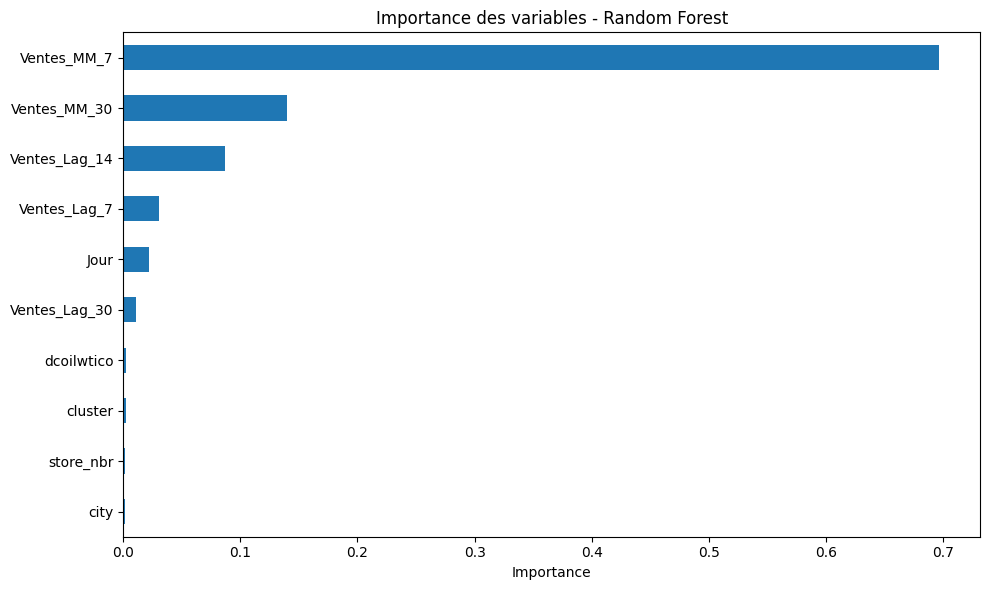

In [ ]:
if hasattr(meilleur_modele, "feature_importances_"):
    importances = pd.Series(
        meilleur_modele.feature_importances_, index=features
    ).sort_values(ascending=False)

    print("\n===== IMPORTANCE DES VARIABLES (Top 10) =====")
    print(importances.head(10))

    plt.figure(figsize=(10, 6))
    importances.head(10).plot(kind="barh")
    plt.title(f"Importance des variables - {meilleur_modele_nom}")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("importance_variables.png", dpi=150)
    print("\nGraphique sauvegardé : importance_variables.png")

8. VISUALISATION : VENTES RÉELLES VS PRÉDITES

Graphique sauvegardé : comparaison_ventes.png


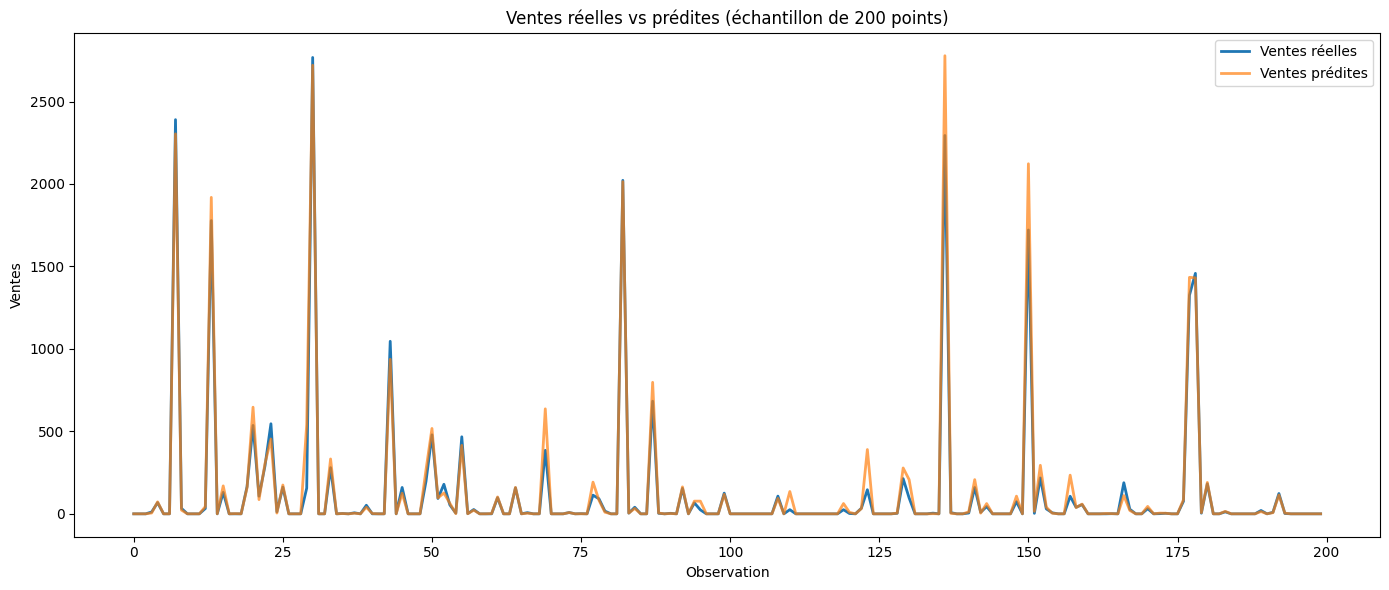

In [ ]:
y_pred_final = meilleur_modele.predict(X_test)

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:200], label="Ventes réelles", linewidth=2)
plt.plot(y_pred_final[:200], label="Ventes prédites", linewidth=2, alpha=0.7)
plt.title("Ventes réelles vs prédites (échantillon de 200 points)")
plt.xlabel("Observation")
plt.ylabel("Ventes")
plt.legend()
plt.tight_layout()
plt.savefig("comparaison_ventes.png", dpi=150)
print("Graphique sauvegardé : comparaison_ventes.png")


# =====================
# 9. SAUVEGARDE DU MODÈLE
# ======================

In [ ]:
joblib.dump(meilleur_modele, "modele_prediction_ventes.pkl")
print("\nModèle sauvegardé : modele_prediction_ventes.pkl")

print("\n=== TERMINÉ ===")
print("Utilisez 'modele_prediction_ventes.pkl' pour prédire de nouvelles ventes")
print("et aider à la décision sur les stocks, achats, marketing et planification.")


Modèle sauvegardé : modele_prediction_ventes.pkl

=== TERMINÉ ===
Utilisez 'modele_prediction_ventes.pkl' pour prédire de nouvelles ventes
et aider à la décision sur les stocks, achats, marketing et planification.
